# **Day 9: Probability and Distributions**
*Module 2 - Probability, Statistics and Optimisation*

ML is built on uncertainty: noisy measurements, random samples, uncertain predictions. **Probability** is the mathematics of uncertainty. Classifiers output probabilities, loss functions come from likelihoods (Day 14), and Bayesian methods (Day 53) are probability all the way down.

> Probability measures how likely something is, and a distribution describes all possible outcomes and their chances. ML models are uncertain, so probability is how we express and reason about that uncertainty.
>
> *Example:* If 30% of a district is cropland, a randomly chosen pixel has probability 0.3 of being cropland before we even look at the image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(9)

## **1. Random Variables**
A **random variable** maps outcomes to numbers.
- **Discrete** (counts, classes): described by a **PMF** $P(X=k)$.
- **Continuous** (temperature, reflectance): described by a **PDF** $f(x)$; probabilities are **areas**: $P(a<X<b)=\int_a^b f(x)dx$.
- The **CDF** $F(x)=P(X\le x)$ works for both.

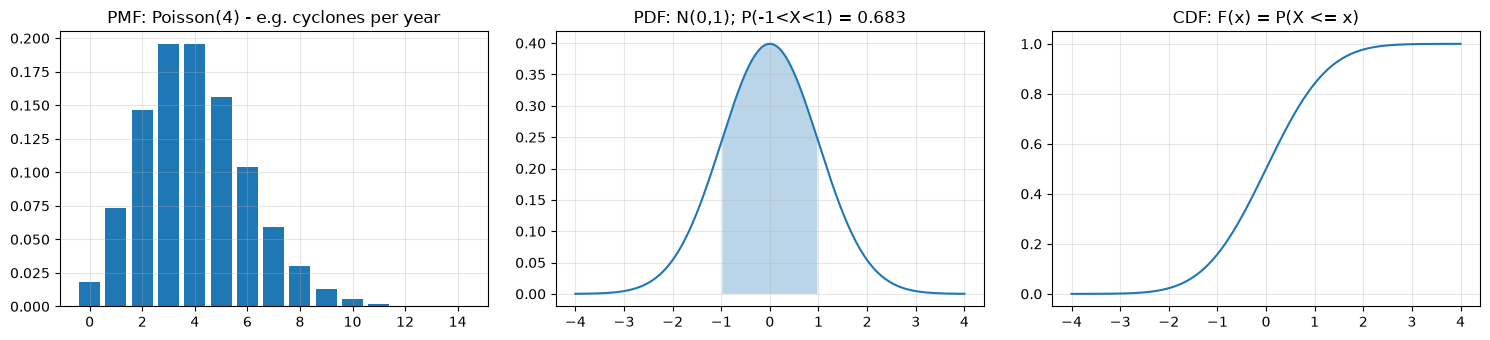

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
k = np.arange(0, 15)
axes[0].bar(k, stats.poisson.pmf(k, 4)); axes[0].set_title("PMF: Poisson(4) - e.g. cyclones per year")
x = np.linspace(-4, 4, 300)
axes[1].plot(x, stats.norm.pdf(x)); axes[1].fill_between(x, stats.norm.pdf(x), where=(x > -1) & (x < 1), alpha=0.3)
axes[1].set_title(f"PDF: N(0,1); P(-1<X<1) = {stats.norm.cdf(1) - stats.norm.cdf(-1):.3f}")
axes[2].plot(x, stats.norm.cdf(x)); axes[2].set_title("CDF: F(x) = P(X <= x)")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## **2. Expectation, Variance, Covariance**
- $\mathbb{E}[X] = \sum_x x P(x)$ or $\int x f(x)dx$ (the long-run average)
- $\text{Var}(X) = \mathbb{E}[(X-\mathbb{E}X)^2] = \mathbb{E}[X^2] - (\mathbb{E}X)^2$
- $\text{Cov}(X,Y) = \mathbb{E}[(X-\mathbb{E}X)(Y-\mathbb{E}Y)]$; correlation $\rho = \text{Cov}/(\sigma_X\sigma_Y)$
- Linearity: $\mathbb{E}[aX+bY] = a\mathbb{E}X + b\mathbb{E}Y$ (always); $\text{Var}(X+Y)=\text{Var}X+\text{Var}Y+2\text{Cov}(X,Y)$

In [3]:
die = np.arange(1, 7)
E = die.mean(); V = ((die - E) ** 2).mean()
rolls = rng.integers(1, 7, 100_000)
print(f"Fair die: E = {E:.3f} (simulated {rolls.mean():.3f}), Var = {V:.3f} (simulated {rolls.var():.3f})")

# Why averaging ensembles helps: Var of the mean of n *correlated* models
for rho in [0.0, 0.5, 0.9]:
    n_models, s2 = 10, 1.0
    var_mean = rho * s2 + (1 - rho) * s2 / n_models
    print(f"rho={rho}: variance of an average of {n_models} models = {var_mean:.2f} (single model 1.00)")

Fair die: E = 3.500 (simulated 3.495), Var = 2.917 (simulated 2.921)
rho=0.0: variance of an average of 10 models = 0.10 (single model 1.00)
rho=0.5: variance of an average of 10 models = 0.55 (single model 1.00)
rho=0.9: variance of an average of 10 models = 0.91 (single model 1.00)


The last result is the mathematical reason **Random Forests** decorrelate their trees (Day 36): averaging only reduces variance when models are not perfectly correlated.

## **3. The Distribution Zoo**

| Distribution | Type | Parameters | ML use |
|---|---|---|---|
| Bernoulli | discrete | $p$ | Binary label; logistic regression |
| Binomial | discrete | $n, p$ | Number of correct predictions |
| Categorical / Multinomial | discrete | $p_1..p_K$ | Multi-class labels; softmax |
| Poisson | discrete | $\lambda$ | Counts; Poisson regression (Day 26) |
| Uniform | continuous | $a, b$ | Random search, initialisation |
| Normal (Gaussian) | continuous | $\mu, \sigma$ | Noise; linear regression; CLT |
| Exponential | continuous | $\lambda$ | Waiting times, survival |
| Gamma | continuous | $k, \theta$ | Positive skewed values (rainfall) |
| Beta | continuous | $\alpha, \beta$ | Probabilities; Bayesian prior for $p$ |
| Multivariate Normal | continuous | $\boldsymbol\mu, \Sigma$ | GMM, QDA, Gaussian processes |

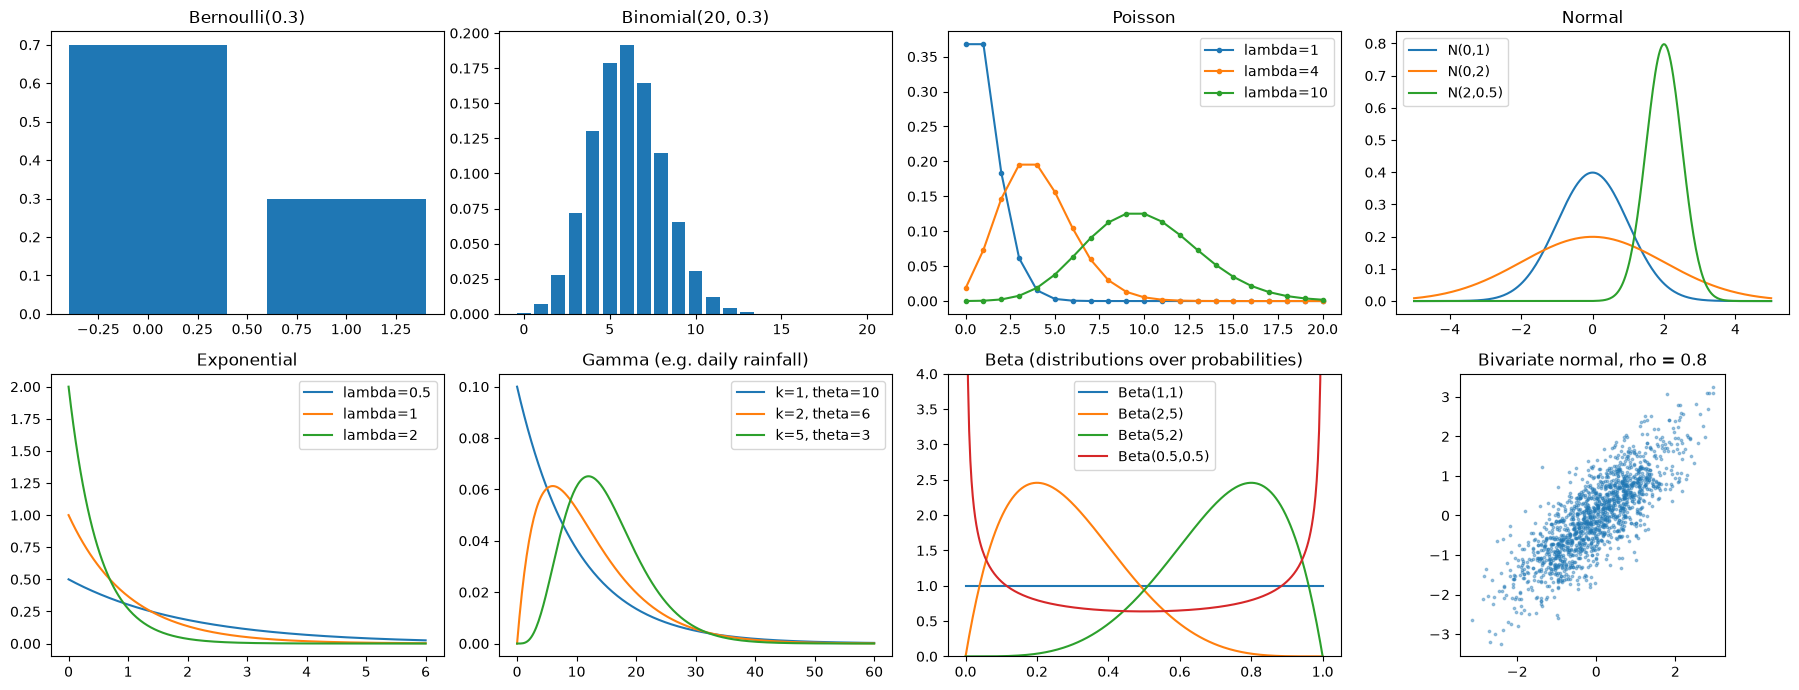

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()
axes[0].bar([0, 1], stats.bernoulli.pmf([0, 1], 0.3)); axes[0].set_title("Bernoulli(0.3)")
kk = np.arange(0, 21); axes[1].bar(kk, stats.binom.pmf(kk, 20, 0.3)); axes[1].set_title("Binomial(20, 0.3)")
for lam in [1, 4, 10]:
    axes[2].plot(kk, stats.poisson.pmf(kk, lam), "o-", ms=3, label=f"lambda={lam}")
axes[2].legend(); axes[2].set_title("Poisson")
xx = np.linspace(-5, 5, 300)
for m, s in [(0, 1), (0, 2), (2, 0.5)]:
    axes[3].plot(xx, stats.norm.pdf(xx, m, s), label=f"N({m},{s})")
axes[3].legend(); axes[3].set_title("Normal")
xp = np.linspace(0, 6, 300)
for lam in [0.5, 1, 2]:
    axes[4].plot(xp, stats.expon.pdf(xp, scale=1 / lam), label=f"lambda={lam}")
axes[4].legend(); axes[4].set_title("Exponential")
xg = np.linspace(0, 60, 300)
for kshape, th in [(1, 10), (2, 6), (5, 3)]:
    axes[5].plot(xg, stats.gamma.pdf(xg, kshape, scale=th), label=f"k={kshape}, theta={th}")
axes[5].legend(); axes[5].set_title("Gamma (e.g. daily rainfall)")
xb = np.linspace(0, 1, 300)
for a, b in [(1, 1), (2, 5), (5, 2), (0.5, 0.5)]:
    axes[6].plot(xb, stats.beta.pdf(xb, a, b), label=f"Beta({a},{b})")
axes[6].legend(); axes[6].set_ylim(0, 4); axes[6].set_title("Beta (distributions over probabilities)")
mvn = rng.multivariate_normal([0, 0], [[1, 0.8], [0.8, 1]], 1500)
axes[7].scatter(*mvn.T, s=3, alpha=0.4); axes[7].set_title("Bivariate normal, rho = 0.8"); axes[7].set_aspect("equal")
plt.tight_layout(); plt.show()

## **4. Joint, Marginal and Conditional Probability**
- **Joint** $P(A,B)$; **marginal** $P(A)=\sum_B P(A,B)$; **conditional** $P(A\mid B)=P(A,B)/P(B)$
- **Independence**: $P(A,B)=P(A)P(B)$. Naive Bayes (Day 31) *assumes* features are conditionally independent given the class.

In [5]:
import pandas as pd
counts = pd.DataFrame([[320, 80], [60, 540]], index=["cloud", "clear"], columns=["bright", "dark"])
joint = counts / counts.values.sum()
print("Joint P(sky, pixel):\n", joint.round(3))
print("\nMarginal P(sky):", joint.sum(1).round(3).to_dict())
print("Conditional P(cloud | bright) =", round(joint.loc["cloud", "bright"] / joint["bright"].sum(), 3))

Joint P(sky, pixel):
        bright  dark
cloud    0.32  0.08
clear    0.06  0.54

Marginal P(sky): {'cloud': 0.4, 'clear': 0.6}
Conditional P(cloud | bright) = 0.842


## **5. Bayes' Theorem**
$$P(H\mid D) = \frac{P(D\mid H)\,P(H)}{P(D)}\qquad \text{posterior} = \frac{\text{likelihood}\times\text{prior}}{\text{evidence}}$$

**The base-rate fallacy:** a disease affects 1% of people. A test has 95% sensitivity and 90% specificity. We test positive. What is the probability we are sick?

In [6]:
prior, sens, spec = 0.01, 0.95, 0.90
p_pos = sens * prior + (1 - spec) * (1 - prior)
posterior = sens * prior / p_pos
print(f"P(sick | positive) = {posterior:.3f}  -> only {posterior:.1%}, not 95%!")

# simulation check
N = 1_000_000
sick = rng.random(N) < prior
positive = np.where(sick, rng.random(N) < sens, rng.random(N) < 1 - spec)
print(f"Simulation: {sick[positive].mean():.3f}")

P(sick | positive) = 0.088  -> only 8.8%, not 95%!
Simulation: 0.089


The same effect explains why a classifier with 95% accuracy for a **rare** class (fraud, landslides, deforestation) produces mostly false alarms (Day 21, 28).

## **6. Law of Large Numbers and Monte Carlo**
The average of many independent samples converges to the expectation. **Monte Carlo** methods estimate any quantity by simulation.

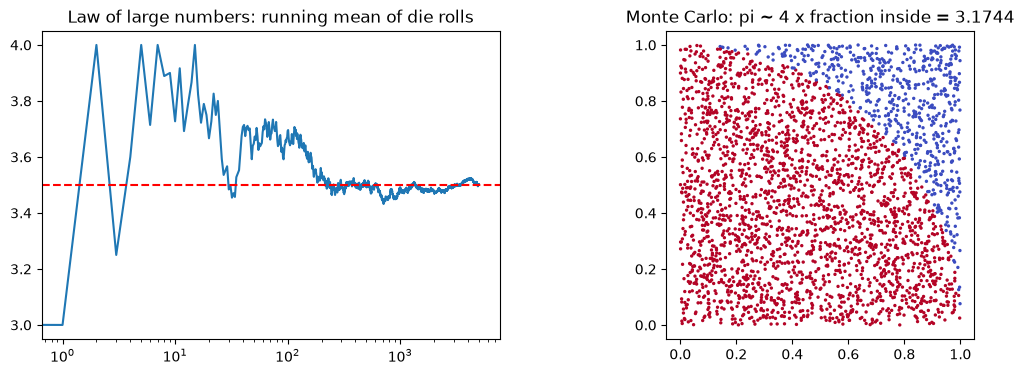

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rolls = rng.integers(1, 7, 5000)
axes[0].plot(np.cumsum(rolls) / np.arange(1, 5001)); axes[0].axhline(3.5, c="r", ls="--")
axes[0].set_xscale("log"); axes[0].set_title("Law of large numbers: running mean of die rolls")

pts = rng.random((20000, 2))
inside = (pts ** 2).sum(1) < 1
axes[1].scatter(*pts[:3000].T, c=inside[:3000], s=2, cmap="coolwarm"); axes[1].set_aspect("equal")
axes[1].set_title(f"Monte Carlo: pi ~ 4 x fraction inside = {4 * inside.mean():.4f}")
plt.show()

# **Part 2: Going Deeper - Sampling from Any Distribution**

**Inverse transform sampling:** if $U\sim\text{Uniform}(0,1)$ then $F^{-1}(U)$ has CDF $F$.
**Rejection sampling:** sample from an easy proposal $g$ and accept with probability $f(x)/(Mg(x))$. These ideas lead to MCMC (Day 53) and diffusion models (Day 73).

Envelope constant M = 5.03


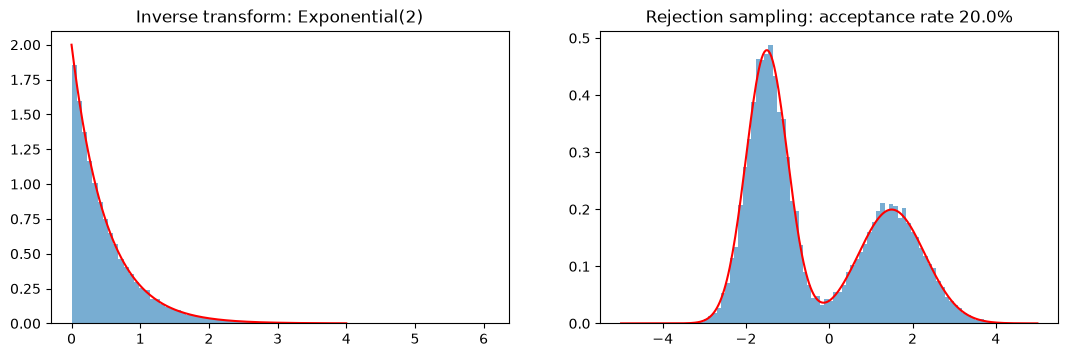

In [8]:
u = rng.random(50000)
exp_samples = -np.log(1 - u) / 2.0                         # inverse CDF of Exponential(lambda=2)

target = lambda x: 0.6 * stats.norm.pdf(x, -1.5, 0.5) + 0.4 * stats.norm.pdf(x, 1.5, 0.8)   # bimodal
xgrid = np.linspace(-5, 5, 2001)
M = 1.05 * target(xgrid).max() / (1 / 10)                  # target <= M * proposal everywhere (proposal pdf = 1/10)
print(f"Envelope constant M = {M:.2f}")
prop = rng.uniform(-5, 5, 100000)
accept = rng.random(100000) < target(prop) / (M * (1 / 10))
rej_samples = prop[accept]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
xe = np.linspace(0, 4, 200)
axes[0].hist(exp_samples, bins=80, density=True, alpha=0.6); axes[0].plot(xe, stats.expon.pdf(xe, scale=0.5), "r")
axes[0].set_title("Inverse transform: Exponential(2)")
xr = np.linspace(-5, 5, 300)
axes[1].hist(rej_samples, bins=80, density=True, alpha=0.6); axes[1].plot(xr, target(xr), "r")
axes[1].set_title(f"Rejection sampling: acceptance rate {accept.mean():.1%}")
plt.show()

## **Practice Problems**
1. A satellite pixel is cloudy with probability 0.35 on any date, independently. Over 12 acquisitions, what is the probability of getting at least 3 clear observations? (Binomial)
2. In the disease example, what prior (prevalence) would make P(sick | positive) = 50%?
3. Estimate $\mathbb{E}[\max(X_1, X_2, X_3)]$ for three independent N(0,1) variables by Monte Carlo.
4. *(Advanced)* Use inverse transform sampling to draw from the Rayleigh distribution, CDF $F(x) = 1 - e^{-x^2/2}$ (used for SAR amplitude).

In [9]:
# Solution 1
print("P(>= 3 clear of 12):", round(1 - stats.binom.cdf(2, 12, 0.65), 4))
# Solution 2: solve sens*p / (sens*p + (1-spec)(1-p)) = 0.5
p50 = (1 - spec) / (sens + (1 - spec))
print(f"prevalence needed: {p50:.3f}")
# Solution 3
print("E[max of 3 N(0,1)] ~", rng.normal(size=(200000, 3)).max(1).mean().round(4), "(exact 0.8463)")
# Solution 4
ray = np.sqrt(-2 * np.log(1 - rng.random(50000)))
print("Rayleigh mean (sim vs exact):", ray.mean().round(4), round(np.sqrt(np.pi / 2), 4))

P(>= 3 clear of 12): 0.9992
prevalence needed: 0.095
E[max of 3 N(0,1)] ~ 0.8468 (exact 0.8463)
Rayleigh mean (sim vs exact): 1.2553 1.2533


## **Key References**
- Blitzstein, J. K., & Hwang, J. (2019). *Introduction to Probability* (2nd ed.). CRC Press.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapters 1-2. Springer.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press.